In [ ]:
import torch as t
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification

In [ ]:
# dataset

<Axes: >

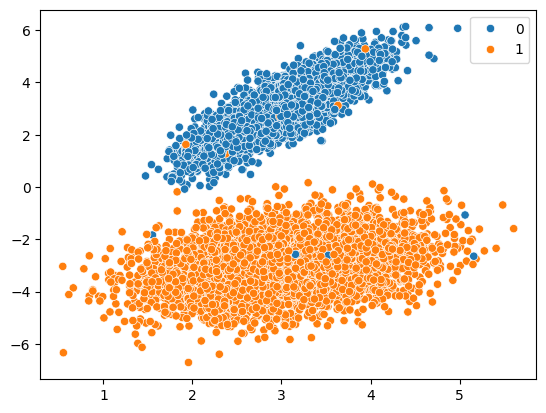

In [ ]:
fv,cv=make_classification(n_samples=10000,n_features=2,n_informative=2,n_redundant=0,random_state=1,n_repeated=0,n_classes=2,class_sep=3,n_clusters_per_class=1)
sns.scatterplot(x=fv[:,0],y=fv[:,1],hue=cv)


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(fv,cv,test_size=0.2,stratify=cv)
x_trainf,x_cv,y_trainf,y_cv=train_test_split(x_train,y_train,test_size=0.2,stratify=y_train)

In [ ]:
"""
train=(x_traif,y_trainf)
cv=(x_cv,y_cv)
test=(x_test,y_test)"""

'\ntrain=(x_traif,y_trainf)\ncv=(x_cv,y_cv)\ntest=(x_test,y_test)'

In [ ]:
from sklearn.preprocessing import StandardScaler
st = StandardScaler()

In [ ]:
x_trains=st.fit_transform(x_trainf)
x_cvs=st.transform(x_cv)
x_tests=st.transform(x_test)

In [ ]:
x_trains=t.from_numpy(x_trains).to(dtype=t.float32)
y_train=t.from_numpy(y_trainf).to(dtype=t.float32)

x_cvs=t.from_numpy(x_cvs).to(dtype=t.float32)
y_cv=t.from_numpy(y_cv).to(dtype=t.float32)

x_tests=t.from_numpy(x_tests).to(dtype=t.float32)
y_test=t.from_numpy(y_test).to(dtype=t.float32)

In [ ]:
class BinarClass(t.nn.Module):
  def __init__(self,n_features):
    super().__init__()

    self.linear=t.nn.Linear(n_features,1)

  def forward(self,data):
    return self.linear(data)

In [ ]:
model=BinarClass(2)
list(model.parameters())

[Parameter containing:
 tensor([[ 0.4096, -0.1344]], requires_grad=True),
 Parameter containing:
 tensor([0.1362], requires_grad=True)]

In [ ]:
model=BinarClass(2)

# define the loss

loss=t.nn.BCEWithLogitsLoss()

# define the optimiser
opt=t.optim.SGD(model.parameters(),lr=0.01)

epochs=2000

train_loss_data=[]
cv_loss_data=[]
for iter in range(epochs):
  model.train()

  predi_t=model(x_trains)

  train_loss=loss(predi_t.squeeze(),y_train)

  opt.zero_grad()

  train_loss.backward()

  opt.step()

  model.eval()

  with t.no_grad():
    predi_cv=model(x_cvs)
    cv_loss=loss(predi_cv.squeeze(),y_cv)

  train_loss_data.append(train_loss.detach().numpy())
  cv_loss_data.append(cv_loss.numpy())

  print("epochs :{}, train_loss :{}, cv_loss :{}".format(iter+1,train_loss,cv_loss))



epochs :1, train_loss :0.4607914090156555, cv_loss :0.46151602268218994
epochs :2, train_loss :0.459628701210022, cv_loss :0.46035832166671753
epochs :3, train_loss :0.4584711194038391, cv_loss :0.4592057168483734
epochs :4, train_loss :0.4573186933994293, cv_loss :0.45805823802948
epochs :5, train_loss :0.4561712145805359, cv_loss :0.4569157361984253
epochs :6, train_loss :0.4550289213657379, cv_loss :0.4557782709598541
epochs :7, train_loss :0.4538916051387787, cv_loss :0.4546458423137665
epochs :8, train_loss :0.4527592360973358, cv_loss :0.45351842045783997
epochs :9, train_loss :0.4516318440437317, cv_loss :0.4523959457874298
epochs :10, train_loss :0.4505094587802887, cv_loss :0.4512783885002136
epochs :11, train_loss :0.4493919312953949, cv_loss :0.4501657485961914
epochs :12, train_loss :0.44827935099601746, cv_loss :0.4490579664707184
epochs :13, train_loss :0.4471715986728668, cv_loss :0.44795501232147217
epochs :14, train_loss :0.44606873393058777, cv_loss :0.446856856346130

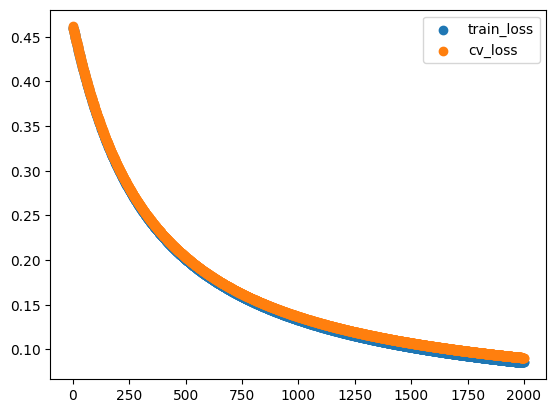

In [ ]:
plt.scatter(range(1,2000+1),train_loss_data,label="train_loss")
plt.scatter(range(1,2000+1),cv_loss_data,label="cv_loss")
plt.legend()
plt.show()

In [ ]:
# gpu

In [ ]:
t.cuda.is_available()

True

In [ ]:
x_trains=t.from_numpy(x_trains).to(dtype=t.float32).cuda()
y_train=t.from_numpy(y_trainf).to(dtype=t.float32).cuda()

x_cvs=t.from_numpy(x_cvs).to(dtype=t.float32).cuda()
y_cv=t.from_numpy(y_cv).to(dtype=t.float32).cuda()

x_tests=t.from_numpy(x_tests).to(dtype=t.float32).cuda()
y_test=t.from_numpy(y_test).to(dtype=t.float32).cuda()

In [ ]:
class BinarClass(t.nn.Module):
  def __init__(self,n_features):
    super().__init__()

    self.linear=t.nn.Linear(n_features,1)

  def forward(self,data):
    return self.linear(data)

In [ ]:
model=BinarClass(2)
model=model.cuda()

# define the loss

loss=t.nn.BCEWithLogitsLoss()

# define the optimiser
opt=t.optim.SGD(model.parameters(),lr=0.01)

epochs=2000

train_loss_data=[]
cv_loss_data=[]
for iter in range(epochs):
  model.train()

  predi_t=model(x_trains)

  train_loss=loss(predi_t.squeeze(),y_train)

  opt.zero_grad()

  train_loss.backward()

  opt.step()

  model.eval()

  with t.no_grad():
    predi_cv=model(x_cvs)
    cv_loss=loss(predi_cv.squeeze(),y_cv)

  train_loss_data.append(train_loss.detach().cpu().numpy())
  cv_loss_data.append(cv_loss.cpu().numpy())

  print("epochs :{}, train_loss :{}, cv_loss :{}".format(iter+1,train_loss,cv_loss))



epochs :1, train_loss :0.5621513724327087, cv_loss :0.5616437196731567
epochs :2, train_loss :0.5604157447814941, cv_loss :0.559903621673584
epochs :3, train_loss :0.5586885213851929, cv_loss :0.558171808719635
epochs :4, train_loss :0.5569695234298706, cv_loss :0.5564482808113098
epochs :5, train_loss :0.5552587509155273, cv_loss :0.5547329783439636
epochs :6, train_loss :0.5535562634468079, cv_loss :0.5530259013175964
epochs :7, train_loss :0.5518618822097778, cv_loss :0.5513269305229187
epochs :8, train_loss :0.550175666809082, cv_loss :0.5496361255645752
epochs :9, train_loss :0.5484976172447205, cv_loss :0.5479534268379211
epochs :10, train_loss :0.5468275547027588, cv_loss :0.5462787747383118
epochs :11, train_loss :0.5451655983924866, cv_loss :0.5446121692657471
epochs :12, train_loss :0.5435115694999695, cv_loss :0.5429534912109375
epochs :13, train_loss :0.5418655276298523, cv_loss :0.5413028001785278
epochs :14, train_loss :0.5402273535728455, cv_loss :0.5396600961685181
epoc

In [ ]:
list(model.parameters())

[Parameter containing:
 tensor([[ 0.3275, -2.9310]], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.1035], device='cuda:0', requires_grad=True)]

In [ ]:
list(model.state_dict())

['linear.weight', 'linear.bias']

In [ ]:
t.save(model.state_dict(),"/content/model1.pt")

In [ ]:
class BinarClass(t.nn.Module):
  def __init__(self,n_features):
    super().__init__()

    self.linear=t.nn.Linear(n_features,1)

  def forward(self,data):
    return self.linear(data)

In [ ]:
model1=BinarClass(2)

In [ ]:
list(model1.parameters())

[Parameter containing:
 tensor([[-0.1563,  0.5798]], requires_grad=True),
 Parameter containing:
 tensor([0.0129], requires_grad=True)]

In [ ]:
model1=model1.load_state_dict(t.load("/content/model1.pt"))

In [ ]:
model1

<All keys matched successfully>

In [ ]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[ 0.3275, -2.9310]], device='cuda:0')),
             ('linear.bias', tensor([0.1035], device='cuda:0'))])